In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("smartcart_customers.csv")

In [3]:
# df.head()
# df.describe()
df.info()
# df.isnull().sum()
# df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
df["Income"]=df["Income"].fillna(df["Income"].median())
# df.isnull().sum()
df.sample()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
111,7431,1991,PhD,Single,68126.0,0,0,10-11-2012,40,1332,...,23,51,86,1,7,4,5,9,0,1


In [5]:
df["Age"]=2026-df["Year_Birth"]

In [6]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date=df["Dt_Customer"].max()
df["Customer_Tenure_Days"]=(reference_date-df["Dt_Customer"]).dt.days

In [7]:
df["Total_spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]
df["Total_Children"]=df["Kidhome"]+df["Teenhome"]

In [8]:
df["Education"].value_counts()
df["Education"]= df["Education"].replace({
                    "Basic":"Undergraduate","2n Cycle":"Undergraduate",
                    "Graduation":"Graduate",
                    "PhD":"Postgraduate","Master":"Postgraduate"
                    })
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [9]:
df["Marital_Status"].value_counts()
df["Living_with"]= df["Marital_Status"].replace({
                    "Married":"Partner","Together":"Partner",
                    "Single":"Alone","Alone":"Alone",
                    "Divorced":"Alone","Widow":"Alone",
                    "Absurd":"Alone","YOLO":"Alone"
                    })
df["Living_with"].value_counts()

Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

In [10]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
cols_drop=cols+spending_cols

In [11]:
df_cleaned=df.drop(columns=cols_drop)

In [12]:
df_cleaned.shape

(2240, 15)

In [13]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'Total_spending', 'Total_Children',
       'Living_with'],
      dtype='object')

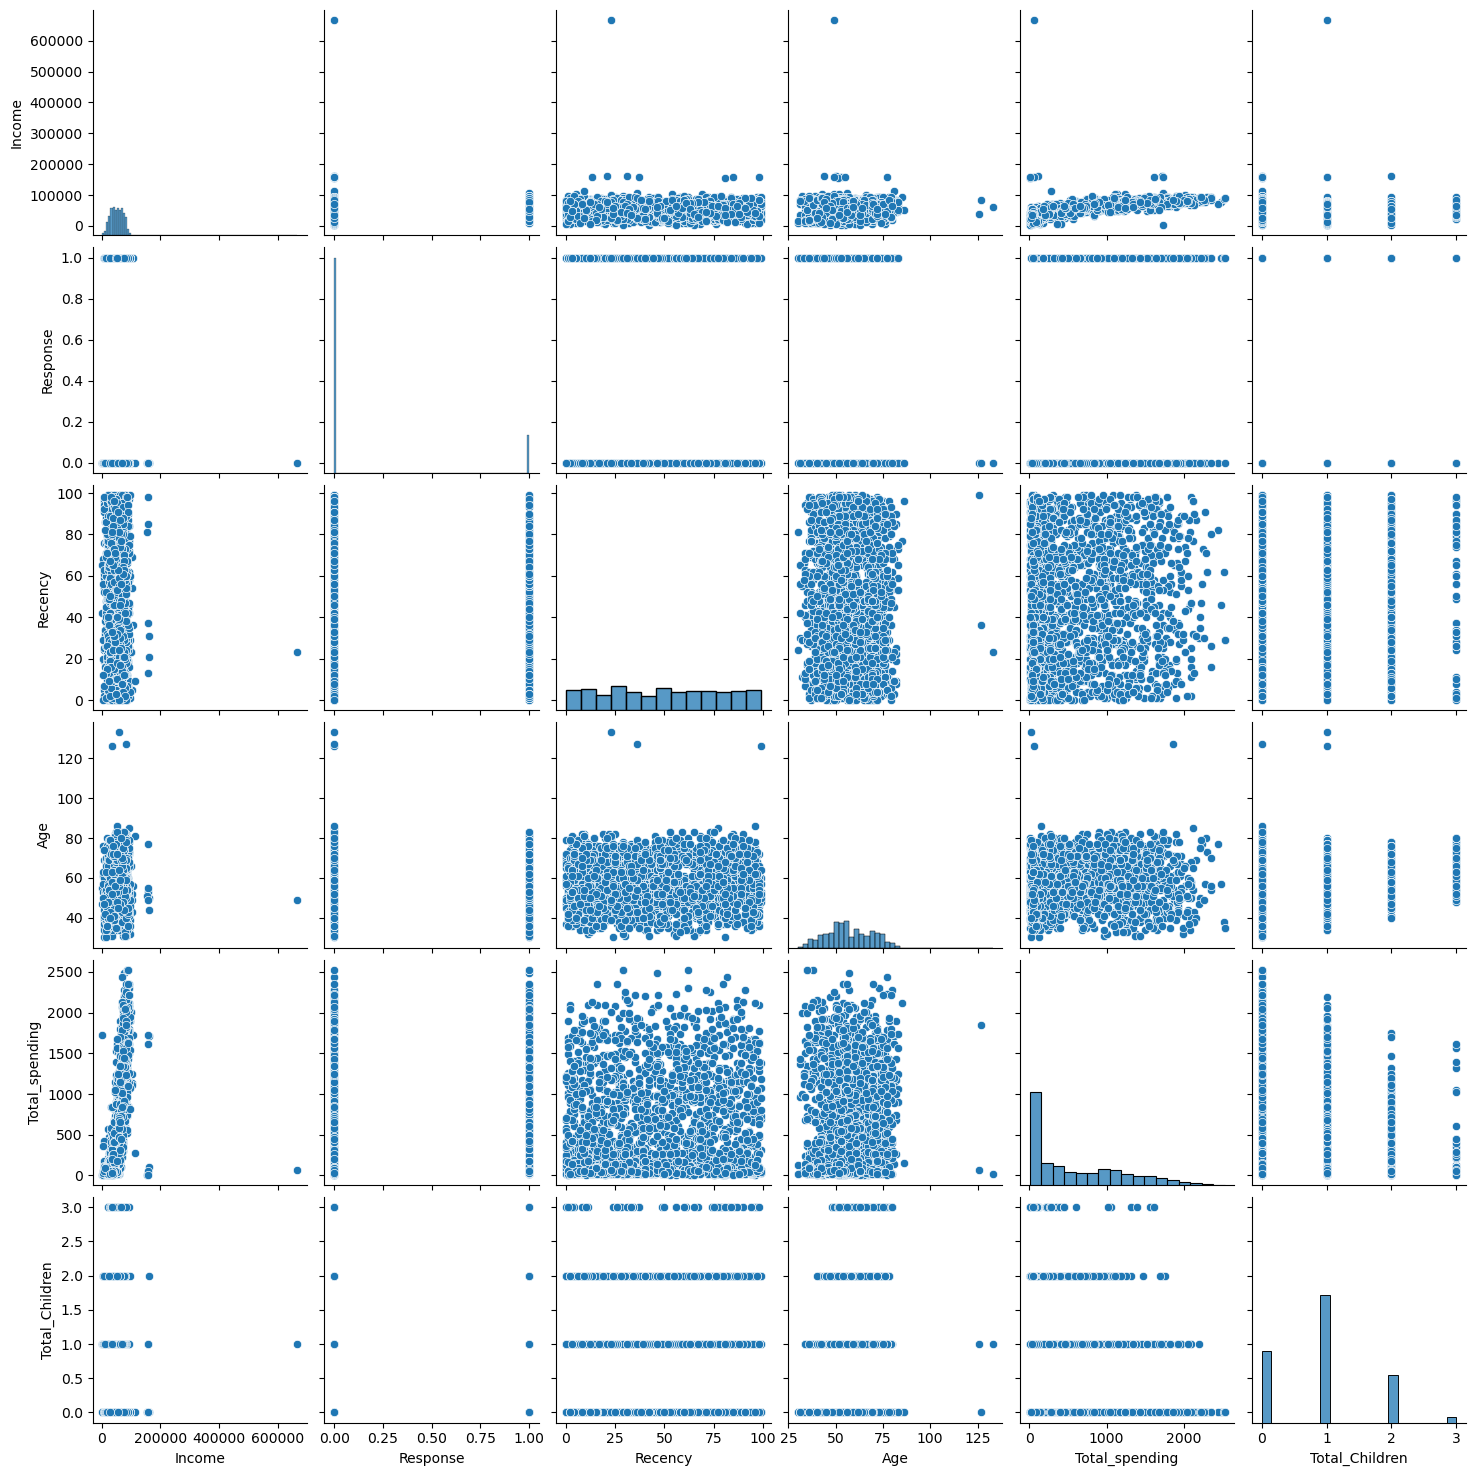

In [14]:
df_cols=["Income","Response","Recency","Age","Total_spending","Total_Children"]

sns.pairplot(df_cleaned[df_cols])        

In [15]:
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600000)]

In [16]:
df_cleaned.shape

(2236, 15)

<Axes: >

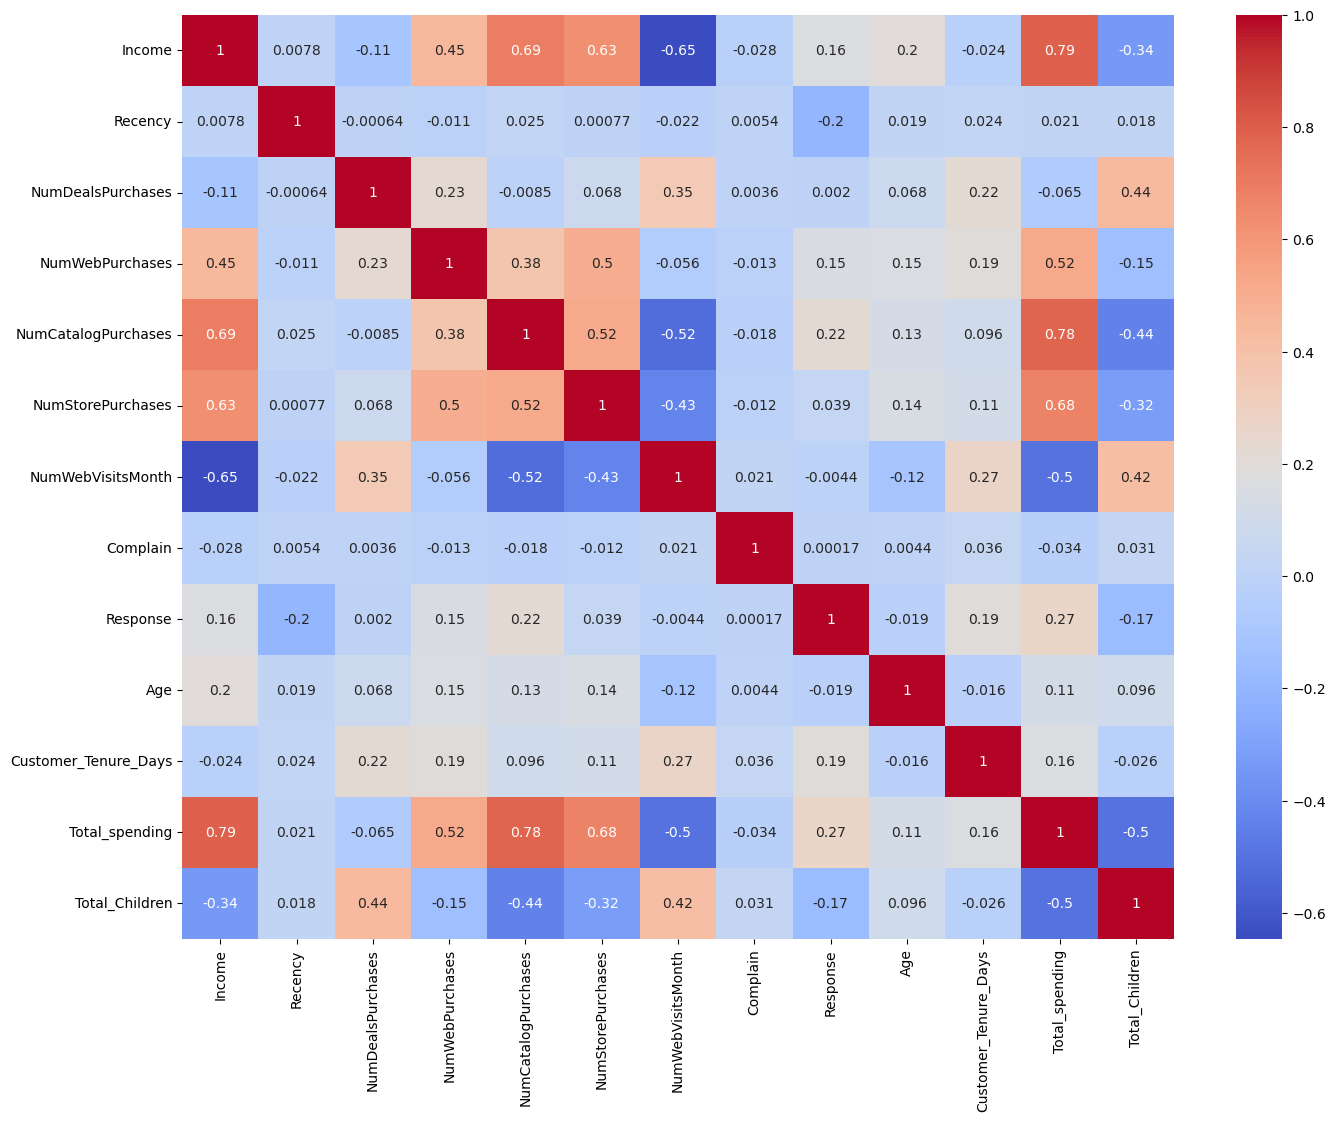

In [17]:
corr=df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(16,12))
sns.heatmap(corr,annot=True,cmap="coolwarm")

In [18]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(sparse_output=False)
cat_cols=["Education","Living_with"]
enc_cols=encoder.fit_transform(df_cleaned[cat_cols])
enc_df=pd.DataFrame(
    enc_cols,
    columns=encoder.get_feature_names_out(cat_cols),
    index=df_cleaned.index
)
enc_df

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...
2235,1.0,0.0,0.0,0.0,1.0
2236,0.0,1.0,0.0,0.0,1.0
2237,1.0,0.0,0.0,1.0,0.0
2238,0.0,1.0,0.0,0.0,1.0


In [19]:
encoded_df=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)
encoded_df.shape

(2236, 18)

In [20]:
from sklearn.preprocessing import StandardScaler
X=encoded_df
scaler=StandardScaler()
X_scaled=scaler.fit_transform(encoded_df)

Text(0.5, 0.92, '3D PROJECTION')

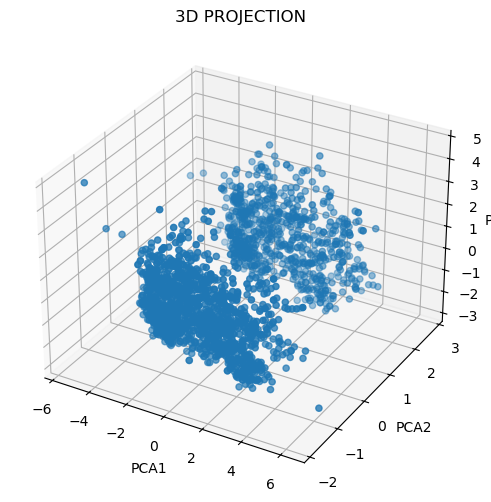

In [21]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_scaled)

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D PROJECTION")

In [22]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

In [23]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)    

C:\Users\vigne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\vigne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\vigne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\vigne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [24]:
from kneed import KneeLocator
K=KneeLocator(x=range(1,11),y=wcss,curve="convex",direction="decreasing")
print("best K:",K.knee)

best K: 4


Text(0, 0.5, 'WCSS')

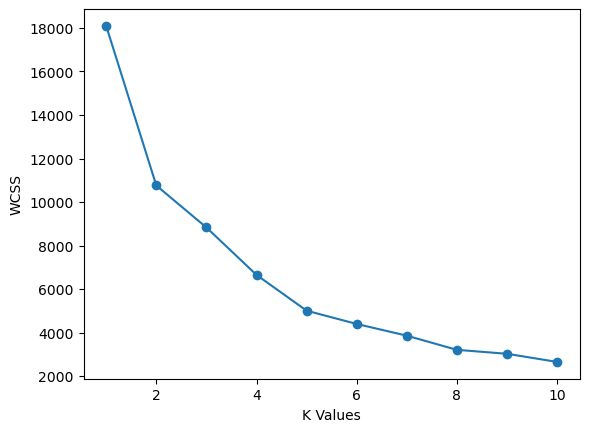

In [25]:
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K Values")
plt.ylabel("WCSS")

In [26]:
from sklearn.metrics import silhouette_score
ss=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    ss.append(score)

C:\Users\vigne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\vigne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\vigne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\vigne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Text(0, 0.5, 'SS')

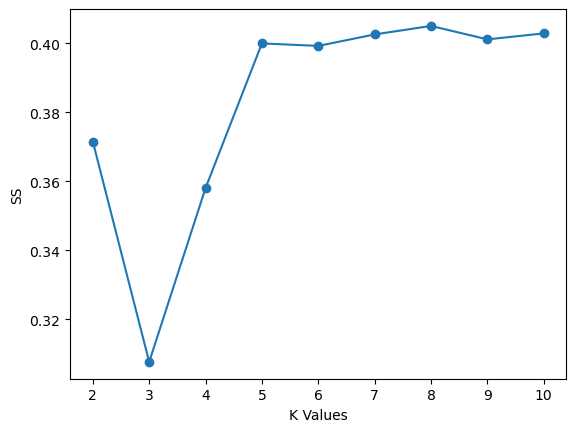

In [27]:
plt.plot(range(2,11),ss,marker='o')
plt.xlabel("K Values")
plt.ylabel("SS")

Text(0, 0.5, 'SILHOUETTE SCORE')

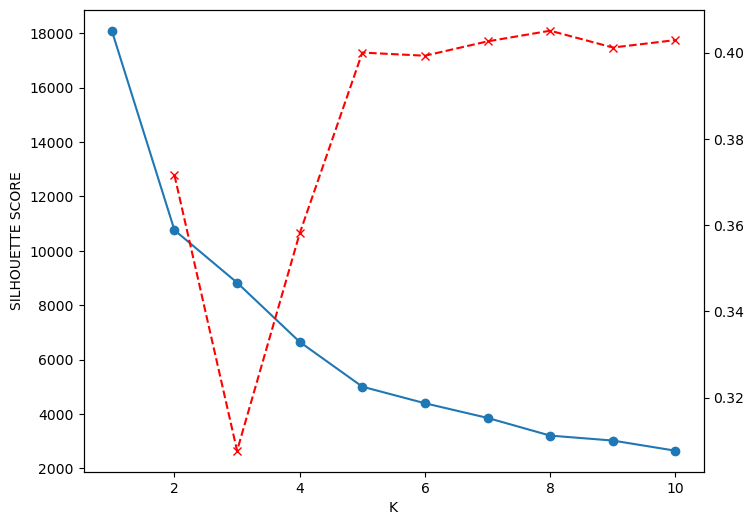

In [28]:
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(8,6))

ax1.plot(range(1,11),wcss,marker='o')
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2=ax1.twinx()
ax2.plot(range(2,11),ss,marker='x',color='red',linestyle="--")
ax1.set_ylabel("SILHOUETTE SCORE")

C:\Users\vigne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Text(0.5, 0.92, '3D PROJECTION')

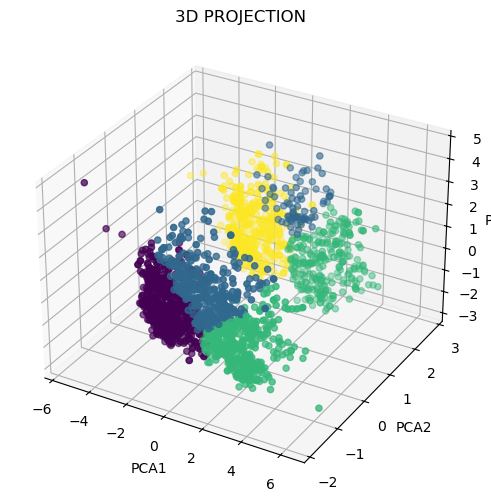

In [29]:
kmeans=KMeans(n_clusters=4,random_state=42)
kmeans_labels=kmeans.fit_predict(X_pca)

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=kmeans_labels)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D PROJECTION")

Text(0.5, 0.92, '3D PROJECTION')

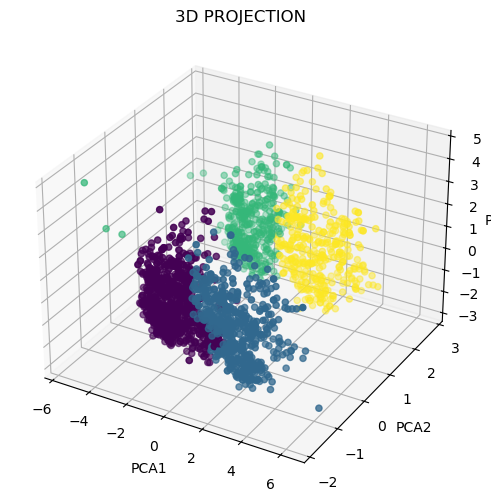

In [30]:
from sklearn.cluster import AgglomerativeClustering
AggC=AgglomerativeClustering(n_clusters=4,linkage="ward")
agg_labels=AggC.fit_predict(X_pca)

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=agg_labels)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D PROJECTION")

In [31]:
X["cluster"]=agg_labels
X

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,0.0,1.0,0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,0.0,1.0,0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,1.0,0.0,3
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,0.0,1.0,1


<Axes: xlabel='cluster', ylabel='count'>

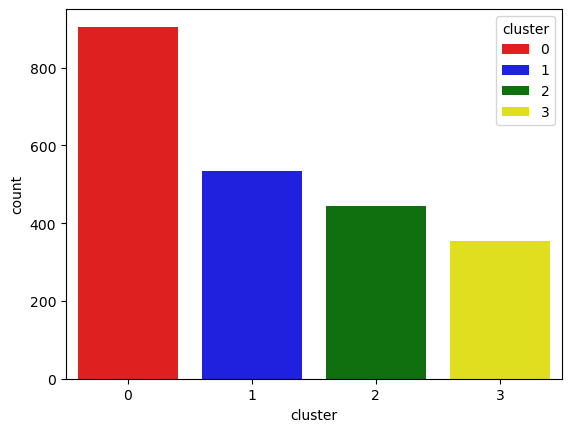

In [32]:
p=["red","blue","green","yellow"]
sns.countplot(x=X["cluster"],palette=p,hue=X["cluster"])

<Axes: xlabel='Total_spending', ylabel='Income'>

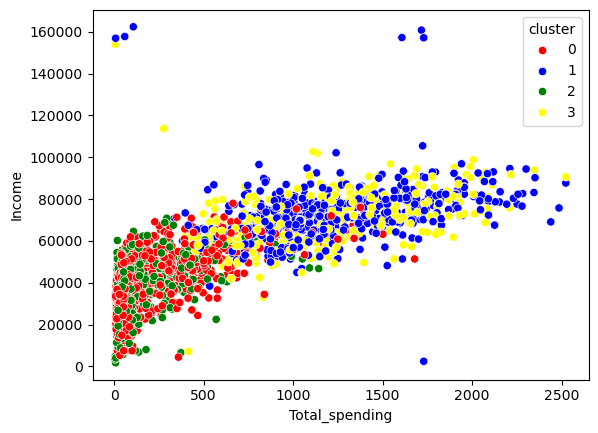

In [33]:
sns.scatterplot(x=X["Total_spending"],y=X["Income"],hue=X["cluster"],palette=p)

In [34]:
#cluster summary
cluster_summary=X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_spending  \
cluster         